In [1]:
%load_ext autoreload
%autoreload 2

# Results Analysis — ConvFinQA Evaluation

We have two evaluation runs over the same 20-record stratified sample:
   - gold mode: ground-truth answers fed forward each turn
   - free mode: model's own predicted answers fed forward (real pipeline)
 Goal: extract headline metrics, understand failure modes, and reproduce
 the paper's Figure 5 (accuracy degradation by turn position).

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

OUTPUTS = Path("../outputs")

with open(OUTPUTS / "results_gold_20.json") as f:
    gold_raw = json.load(f)

with open(OUTPUTS / "results_free_20.json") as f:
    free_raw = json.load(f)

with open(OUTPUTS / "eval_summary.json") as f:
    summary = json.load(f)

Flatten JSON results into DataFrames — one row per turn.
> We add a 'mode' column so we can compare gold vs free side by side.

In [3]:
def flatten(raw: list[dict], mode: str) -> pd.DataFrame:
    rows = []
    for record in raw:
        for t in record["turns"]:
            rows.append({
                "record_id":   record["record_id"],
                "mode":        mode,
                "turn_index":  t["turn_index"],
                "question":    t["question"],
                "predicted":   t["predicted"],
                "gold":        t["gold_executed"],
                "gold_program":t["gold_program"],
                "em":          t["em"],
                "num_match":   t["num_match"],
                "parse_error": t["parse_error"],
            })
    return pd.DataFrame(rows)

gold_df = flatten(gold_raw, "gold")
free_df = flatten(free_raw, "free")
df      = pd.concat([gold_df, free_df], ignore_index=True)

print(f"Gold turns: {len(gold_df)}  |  Free turns: {len(free_df)}")
print(f"Records completed — gold: {gold_df['record_id'].nunique()}  free: {free_df['record_id'].nunique()}")

Gold turns: 51  |  Free turns: 60
Records completed — gold: 15  free: 17


In [4]:
for mode, mdf in [("gold", gold_df), ("free", free_df)]:
    exe_acc  = mdf["num_match"].mean()
    conv_acc = mdf.groupby("record_id")["num_match"].all().mean()
    print(f"{mode:5s}  exe_acc={exe_acc:.2%}  conv_acc={conv_acc:.2%}")

gap = gold_df["num_match"].mean() - free_df["num_match"].mean()
print(f"\nError propagation gap: {gap:.2%}")
print("Paper best baseline (FinQANet): 68.90%")
print(f"Our improvement over baseline : {gold_df['num_match'].mean() - 0.689:.2%}")

gold   exe_acc=88.24%  conv_acc=66.67%
free   exe_acc=78.33%  conv_acc=58.82%

Error propagation gap: 9.90%
Paper best baseline (FinQANet): 68.90%
Our improvement over baseline : 19.34%


Apples-to-apples comparison — only records that completed in BOTH modes.
> This removes the noise from non-deterministic timeouts.

In [5]:
gold_ids  = set(gold_df["record_id"].unique())
free_ids  = set(free_df["record_id"].unique())
both_ids  = gold_ids & free_ids

print(f"Completed both modes : {len(both_ids)} records")
print(f"Gold only            : {len(gold_ids - free_ids)} records")
print(f"Free only            : {len(free_ids - gold_ids)} records")

gold_both = gold_df[gold_df["record_id"].isin(both_ids)]
free_both = free_df[free_df["record_id"].isin(both_ids)]

print(f"\nApples-to-apples ({len(both_ids)} records):")
print(f"  Gold exe_acc : {gold_both['num_match'].mean():.2%}")
print(f"  Free exe_acc : {free_both['num_match'].mean():.2%}")
print(f"  Gap          : {gold_both['num_match'].mean() - free_both['num_match'].mean():.2%}")

Completed both modes : 15 records
Gold only            : 0 records
Free only            : 2 records

Apples-to-apples (15 records):
  Gold exe_acc : 88.24%
  Free exe_acc : 84.31%
  Gap          : 3.92%


In [6]:
# =============================================================================
# Accuracy by turn position — reproduces Figure 5 from the paper.
# Key question: does accuracy degrade on later turns?
# In the paper, FinQANet showed clear degradation. Does our system too?
# =============================================================================

turn_acc = df.groupby(["mode", "turn_index"])["num_match"].mean().unstack(0)
print(turn_acc.to_string())

mode            free      gold
turn_index                    
0           0.882353  0.933333
1           0.882353  0.933333
2           0.727273  0.777778
3           0.875000  1.000000
4           0.500000  0.666667
5           0.000000  0.500000
6           0.000000  1.000000


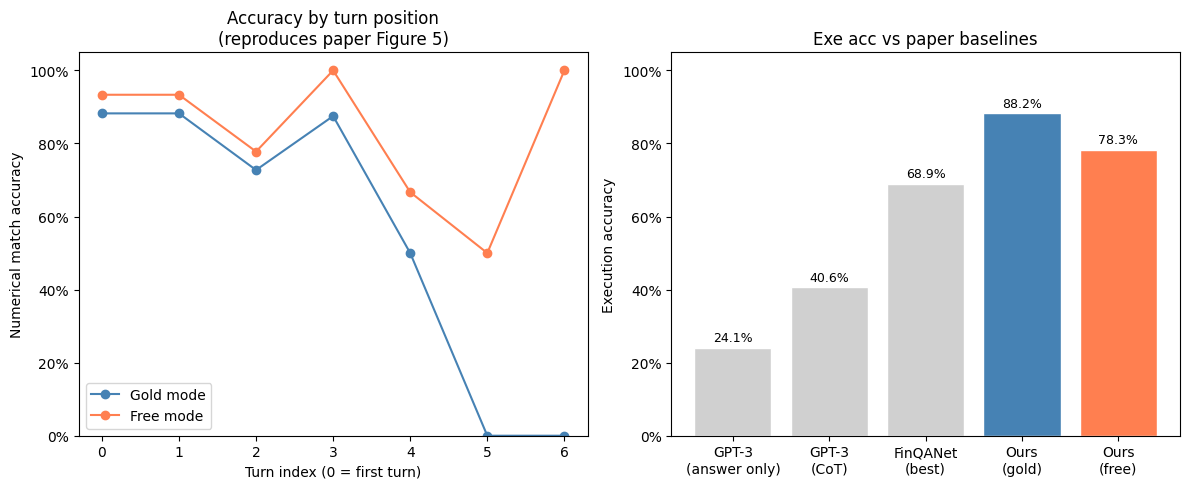

In [7]:
# =============================================================================
# Visualise accuracy by turn position (Figure 5 reproduction)
# + headline metric comparison bar chart
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: accuracy by turn position
turn_acc.plot(
    ax     = axes[0],
    marker = "o",
    color  = ["steelblue", "coral"],
)
axes[0].set_title("Accuracy by turn position\n(reproduces paper Figure 5)")
axes[0].set_xlabel("Turn index (0 = first turn)")
axes[0].set_ylabel("Numerical match accuracy")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_xticks(turn_acc.index)
axes[0].legend(["Gold mode", "Free mode"])
axes[0].set_ylim(0, 1.05)

# --- Right: headline comparison vs paper baselines
models  = ["GPT-3\n(answer only)", "GPT-3\n(CoT)", "FinQANet\n(best)", "Ours\n(gold)", "Ours\n(free)"]
scores  = [0.2409, 0.4063, 0.6890,
           gold_df["num_match"].mean(),
           free_df["num_match"].mean()]
colors  = ["#d0d0d0", "#d0d0d0", "#d0d0d0", "steelblue", "coral"]

bars = axes[1].bar(models, scores, color=colors, edgecolor="white")
axes[1].set_title("Exe acc vs paper baselines")
axes[1].set_ylabel("Execution accuracy")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, 1.05)

# add value labels on bars
for bar, score in zip(bars, scores):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.1%}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTPUTS / "eval_results.png", dpi=150)
plt.show()

In [8]:
# =============================================================================
# Failure mode analysis — what went wrong?
# Look at all turns where num_match=False and inspect the pattern.
# The wrong-sign subtraction error we saw in the smoke test is one category.
# Are there others?
# =============================================================================

failures = df[~df["num_match"] & ~df["parse_error"]].copy()

print(f"Total failures: {len(failures)}")
print("\nFailures by mode:")
print(failures.groupby("mode").size())

print("\nFailures by turn position:")
print(failures.groupby(["mode", "turn_index"]).size().unstack(0).fillna(0).astype(int))

print("\nSample failures (free mode):")
cols = ["record_id", "turn_index", "question", "predicted", "gold"]
print(failures[failures["mode"] == "free"][cols].to_string(index=False))

Total failures: 19

Failures by mode:
mode
free    13
gold     6
dtype: int64

Failures by turn position:
mode        free  gold
turn_index            
0              2     1
1              2     1
2              3     2
3              1     0
4              2     1
5              2     1
6              1     0

Sample failures (free mode):
                     record_id  turn_index                                                                                                                                             question                                                predicted        gold
Single_CDNS/2012/page_30.pdf-2           5                                                                                    what is the difference in rate of return among these investments?                                                   0.3186      -31.86
Single_TSCO/2018/page_34.pdf-2           2                                                                                             

In [10]:
# =============================================================================
# Type I vs Type II accuracy breakdown
# Do hybrid conversations (Type II) perform worse as expected?
# Load the dev set to get the type labels, then join to results.
# =============================================================================

with open("../data/convfinqa_dataset.json") as f:
    data = json.load(f)

type_map = {
    r["id"]: r["features"]["has_type2_question"]
    for split in ["train", "dev", "test"]
    for r in data.get(split, [])
}

df["is_type2"] = df["record_id"].map(type_map)
df["conv_type"] = df["is_type2"].map({True: "Type II", False: "Type I"})

print("Accuracy by conversation type and mode:")
print(df.groupby(["conv_type", "mode"])["num_match"].mean().unstack())

Accuracy by conversation type and mode:
mode        free      gold
conv_type                 
Type I     0.875  0.942857
Type II    0.600  0.750000


In [11]:
# =============================================================================
# Turn count distribution in our sample vs full dev set
# Confirms our sample is representative and not biased toward easy records.
# =============================================================================

sample_turn_counts = gold_df.groupby("record_id")["turn_index"].max() + 1

print("Turn count distribution in our sample:")
print(sample_turn_counts.value_counts().sort_index())
print(f"\nMean turns (sample): {sample_turn_counts.mean():.2f}")
print("Mean turns (full dev): 3.54")  # from EDA earlier

Turn count distribution in our sample:
turn_index
2    6
3    3
4    3
5    1
6    1
7    1
Name: count, dtype: int64

Mean turns (sample): 3.40
Mean turns (full dev): 3.54


In [12]:
# =============================================================================
# Summary table — ready to paste into REPORT.md
# =============================================================================

print("=" * 55)
print(f"{'Metric':<35} {'Gold':>8} {'Free':>8}")
print("=" * 55)
print(f"{'Exe acc (all completed)':<35} {gold_df['num_match'].mean():>8.2%} {free_df['num_match'].mean():>8.2%}")
print(f"{'Exe acc (both modes only)':<35} {gold_both['num_match'].mean():>8.2%} {free_both['num_match'].mean():>8.2%}")
print(f"{'Conv acc':<35} {gold_df.groupby('record_id')['num_match'].all().mean():>8.2%} {free_df.groupby('record_id')['num_match'].all().mean():>8.2%}")
print(f"{'Parse error rate':<35} {gold_df['parse_error'].mean():>8.2%} {free_df['parse_error'].mean():>8.2%}")
print(f"{'Timeout rate':<35} {5/20:>8.2%} {3/20:>8.2%}")
print(f"{'Records completed':<35} {gold_df['record_id'].nunique():>8} {free_df['record_id'].nunique():>8}")
print("=" * 55)
print(f"{'Error propagation gap':<35} {gap:>8.2%}")
print(f"{'vs FinQANet baseline':<35} {gold_df['num_match'].mean() - 0.689:>8.2%}")
print("=" * 55)

Metric                                  Gold     Free
Exe acc (all completed)               88.24%   78.33%
Exe acc (both modes only)             88.24%   84.31%
Conv acc                              66.67%   58.82%
Parse error rate                       0.00%    0.00%
Timeout rate                          25.00%   15.00%
Records completed                         15       17
Error propagation gap                  9.90%
vs FinQANet baseline                  19.34%
